In [1]:
#exercise 1

In [2]:
import csv

def process_student_records(file_path: str) -> None:
    """
    Leest een CSV-bestand met studentgegevens, berekent het gemiddelde cijfer
    en print een rapport van studenten met een cijfer van 80 of hoger.
    Parameters: Het pad naar het CSV-bestand met studentrecords.(file_path : str)
    Returns: Print het gemiddelde cijfer en een rapport van studenten die voldoen
        aan de score-eis.
    Gemaakt door Fleur
    """

    records = []
    with open(file_path, 'r') as file:
        csv_reader = csv.DictReader(file)
        for row in csv_reader:
            records.append(row)


    total = sum(float(record['Grade']) for record in records)
    average = total / len(records)
    print(f"Average Grade: {average}")
    print("--------------------")


    filtered_records = [
        record for record in records
        if float(record['Grade']) >= 80.0
    ]

    print("Student Report")
    print("--------------")
    for record in filtered_records:
        print(f"Name: {record['Name']}")
        print(f"Grade: {record['Grade']}")
        print("--------------------")


In [3]:
# exercise 2

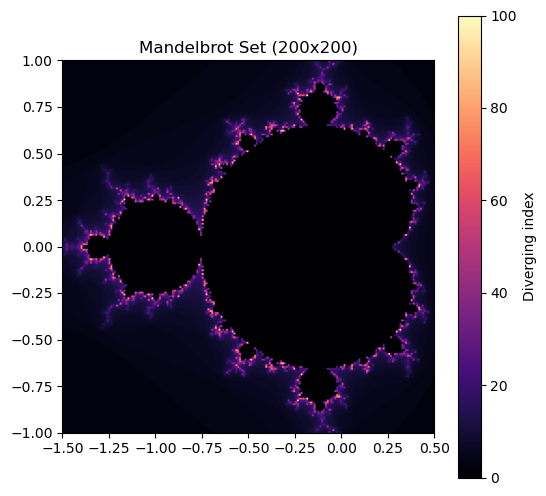

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def draw_mandel(width: int) -> None:
    """
    Tekent een Mandelbrot-afbeelding van grootte width x width.
    Parameters: Breedte en hoogte van het vierkante beeld. width : int
    Returns: Laat de Mandelbrot-afbeelding zien.
    Gemaakt door Fleur
    """

    x = np.linspace(-1.5, 0.5, width)
    y = np.linspace(-1.0, 1.0, width)
    X, Y = np.meshgrid(x, y)
    image = np.zeros((width, width))

    for i in range(width):
        for j in range(width):
            c = complex(X[i, j], Y[i, j])
            a = 0
            diverge_index = 0

            for n in range(1, 101):  # max 100 iteraties
                a = a*a + c
                if abs(a) > 2:
                    diverge_index = n
                    break

            image[i, j] = diverge_index

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="magma", extent=(-1.5, 0.5, -1, 1))
    plt.title(f"Mandelbrot Set ({width}x{width})")
    plt.colorbar(label="Diverging index")
    plt.show()

draw_mandel(200)

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import random

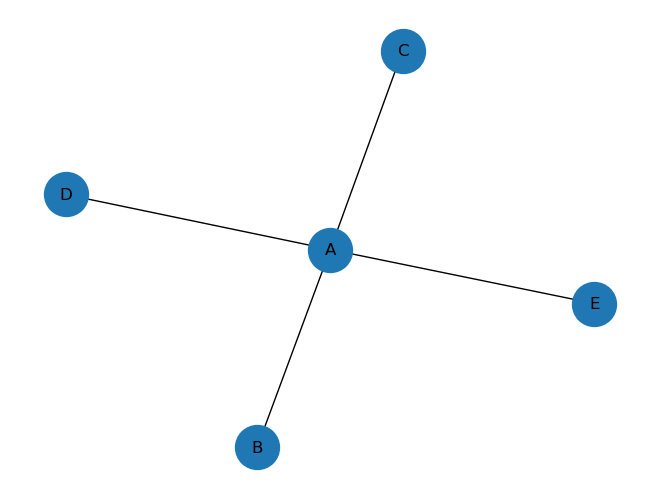

In [6]:
#Make an empty network
graph = nx.Graph()
#Add pages
graph.add_nodes_from(["A", "B", "C", "D", "E"])
#Add edges
edges = [("A", "B"),
    ("A", "C"),
    ("A", "D"),
    ("A", "E")]
graph.add_edges_from(edges)
#Draw the graph
nx.draw(graph, with_labels=True, node_size = 1000)
plt.show()

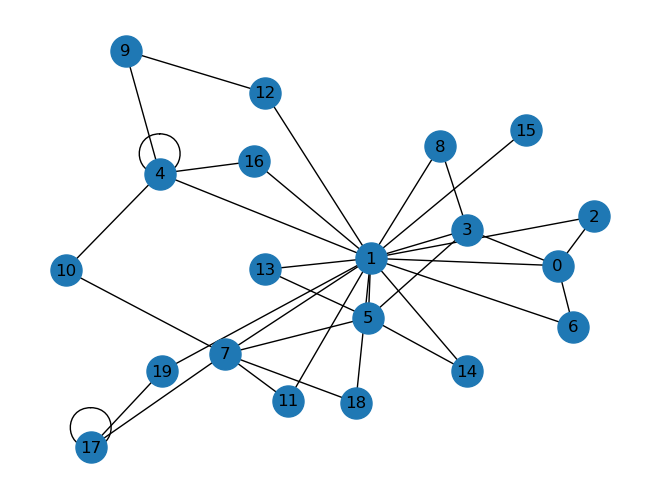

In [7]:
def create_network(
      number_of_nodes: int,
      edges_per_node: int
) -> nx.Graph:
    """Create a growing undirected network manually.
    New nodes preferentially attach to existing nodes with higher degrees.
    Arguments:
    number_of_nodes: The total number of nodes in the network.
    edges_per_node: The number of edges to attach from a new node to existing nodes.
    Returns:
    A networkx undirected graph.
    Worked on by Jeanuar"""

    graph = nx.Graph()
    graph.add_edges_from([(0,1), (1,2), (2,0)])

    #Add new nodes one by one
    for new_node in range(3, number_of_nodes):
        graph.add_node(new_node)

        for _ in range(edges_per_node):
            #higher degree nodes have a higher probability of being chosen
            nodes = list(graph.nodes())
            weights = [graph.degree(node) for node in nodes]

            #Choose a node weighted by degree
            target = random.choices(nodes, weights=weights, k=1)[0]

            if not graph.has_edge(new_node, target):
                graph.add_edge(new_node, target)

    return graph
#Create a network with 20 nodes
graph = create_network(20, 2)
#display the network
nx.draw(graph, with_labels=True, node_size=500)
plt.show()

In [8]:
def simulate_pagerank(
        graph: nx.Graph,
        steps: int = 10000

) -> dict[int, float]:
    """Estimate PageRank by simulating a random surfer.
    The surfer starts at a random node and keeps moving 
    to a randomly selected neighbor.
    Arguments:
    graph: The network to explore
    steps: Number of moves to simulate
    Return:
    A dictionary mapping each node to its estimated PageRank probability.
    Worked on by Jeanuar"""

    nodes = list(graph.nodes())

    #Start at a random node
    current_node = random.choice(nodes)
    #Count how many times we visit each node
    visits = {node: 0 for node in nodes}

    for _ in range(steps):
        visits[current_node] += 1
        #Move to a randomly selected neighbor
        neighbors = list(graph.neighbors(current_node))
        current_node = random.choice(neighbors)

    #Convert visit counts into probabilities
    total_visits = sum(visits.values())

    pagerank = { node: count / total_visits 
                for node, count in visits.items() }
    return pagerank

#Estimate PageRank for your network
pagerank = simulate_pagerank(graph)
#Print the results
for node, score in pagerank.items():
    print(f"Node {node}: {score:.4f}")

Node 0: 0.0586
Node 1: 0.2354
Node 2: 0.0282
Node 3: 0.0554
Node 4: 0.0707
Node 5: 0.0745
Node 6: 0.0298
Node 7: 0.0875
Node 8: 0.0285
Node 9: 0.0272
Node 10: 0.0325
Node 11: 0.0287
Node 12: 0.0294
Node 13: 0.0325
Node 14: 0.0298
Node 15: 0.0146
Node 16: 0.0313
Node 17: 0.0447
Node 18: 0.0306
Node 19: 0.0301


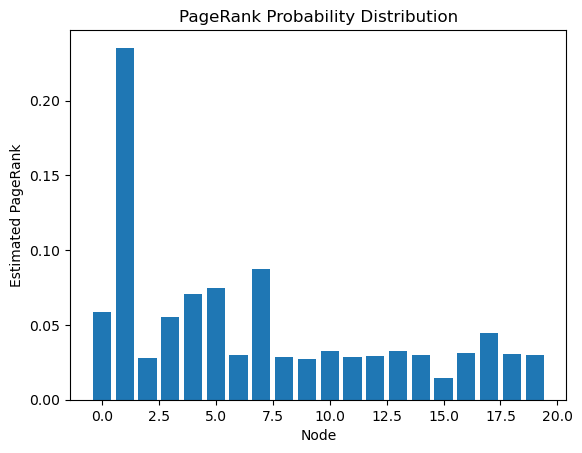

Total probability: 1.0


In [9]:
def plot_pagerank(pagerank: dict[int, float]) -> None:
    """Plot the PageRank scores as a bar chart.
    Arguments:
    pagerank: Dictionary mapping nodes to PageRank scores.
    Returns: None
    Worked on by Jeanuar"""
    nodes = list(pagerank.keys())
    scores = list(pagerank.values())
    plt.bar(nodes, scores)
    plt.xlabel("Node")
    plt.ylabel("Estimated PageRank")
    plt.title("PageRank Probability Distribution")
    plt.show()

#Plot the results
plot_pagerank(pagerank)
total = sum(pagerank.values())
print(f"Total probability: {total}")


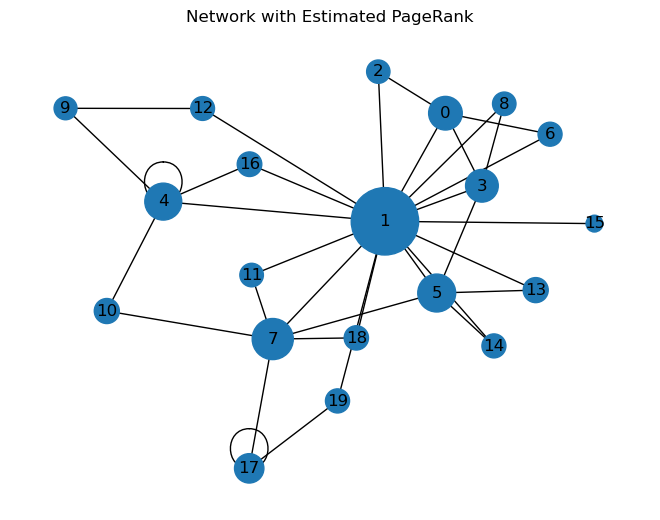

In [10]:
def draw_pagerank( graph: nx.Graph, pagerank: dict[int, float]) -> None:
    """Draw the network with node size based on PageRank.
    Arguments:
    Graph: The network to visualize.
    Pagerank: Estimated PageRank for each node.
    Returns: None
    Worked on by Jeanuar"""

    #Scale the PageRank
    sizes = [pagerank[node] * 10000 for node in graph.nodes()]

    nx.draw(graph, with_labels= True, node_size=sizes)
    plt.title("Network with Estimated PageRank")
    plt.show()

draw_pagerank(graph, pagerank)

In [11]:
#Calculate PageRank with NetworkX built-in function
nx_pagerank = nx.pagerank(graph)
#Print both results
print("Node| Simulation | NetworkX")
for node in graph.nodes():
    print(
        f"{node:4} | "
        f"{pagerank[node]:.4f} | "
        f"{nx_pagerank[node]:.4f}"
    )

Node| Simulation | NetworkX
   0 | 0.0586 | 0.0575
   1 | 0.2354 | 0.2170
   2 | 0.0282 | 0.0312
   3 | 0.0554 | 0.0561
   4 | 0.0707 | 0.0727
   5 | 0.0745 | 0.0689
   6 | 0.0298 | 0.0312
   7 | 0.0875 | 0.0834
   8 | 0.0285 | 0.0310
   9 | 0.0272 | 0.0341
  10 | 0.0325 | 0.0317
  11 | 0.0287 | 0.0308
  12 | 0.0294 | 0.0335
  13 | 0.0325 | 0.0307
  14 | 0.0298 | 0.0307
  15 | 0.0146 | 0.0190
  16 | 0.0313 | 0.0314
  17 | 0.0447 | 0.0460
  18 | 0.0306 | 0.0308
  19 | 0.0301 | 0.0321


In [20]:
## Exercise 3.2: directed network
import pandas as pd 
edges_df = pd.read_csv("squirrel_edges.csv")
edges_df.head()

,id1,id2
0,3475,2849
1,3475,3106
2,3475,808
3,3475,4555
4,3475,3563


In [21]:
def create_directed_network(
        edges_df: pd.DataFrame
) -> nx.DiGraph:
    """Create a directed graph from atricle regrences edges.
    arguments: edges_df: DataFrame with source and target article columns.
    returns: A networkx directed graph.
    Worked on by Jeanuar"""

    graph = nx.DiGraph()
    edges = list(edges_df.itertuples(index= False, name=None))
    graph.add_edges_from(edges)
    return graph

directed_graph = create_directed_network(edges_df)
print("Number of nodes:", directed_graph.number_of_nodes())
print("Number of edges:", directed_graph.number_of_edges())

Number of nodes: 5201
Number of edges: 217073


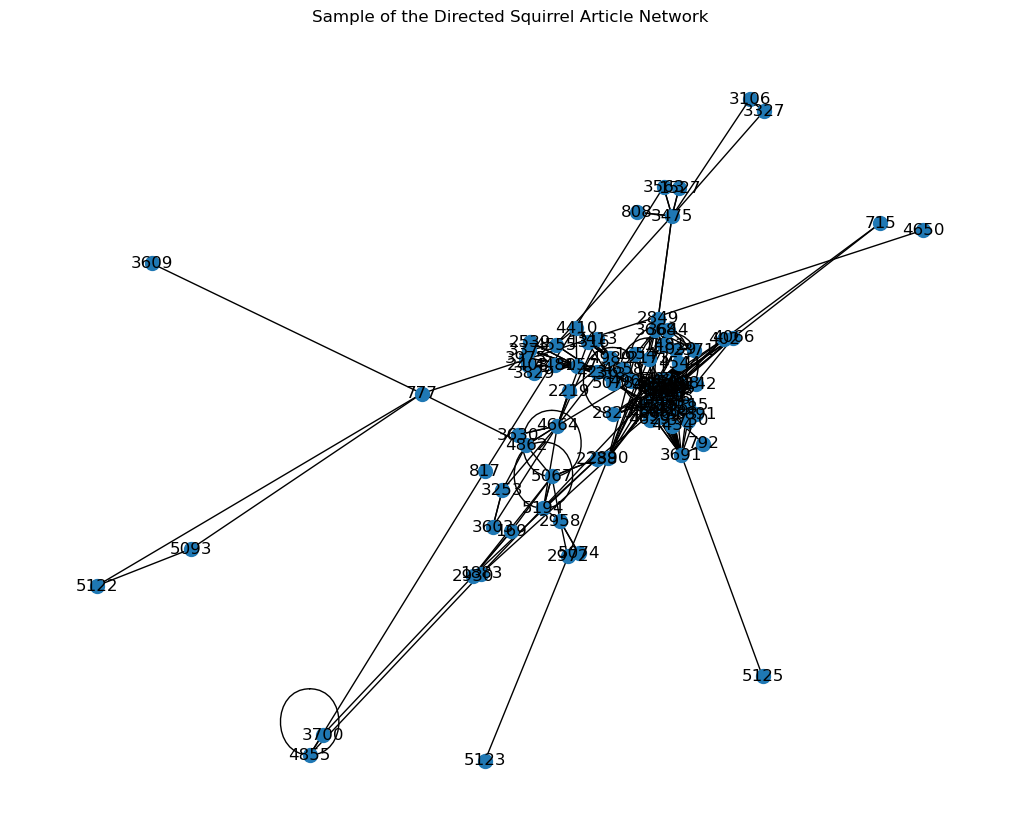

In [ ]:

sample_nodes = list(directed_graph.nodes())[:100]
sample_graph = directed_graph.subgraph(sample_nodes)
plt.figure(figsize=(10, 8))

nx.draw(
    sample_graph,
    with_labels=True,
    node_size=100,
    arrows=False
)

plt.title("sample of the Directed Squirrel article network")
plt.show()